Aggregating dynamic climate files...
Loading static attributes and merging...
Running PCA on 19 total features...


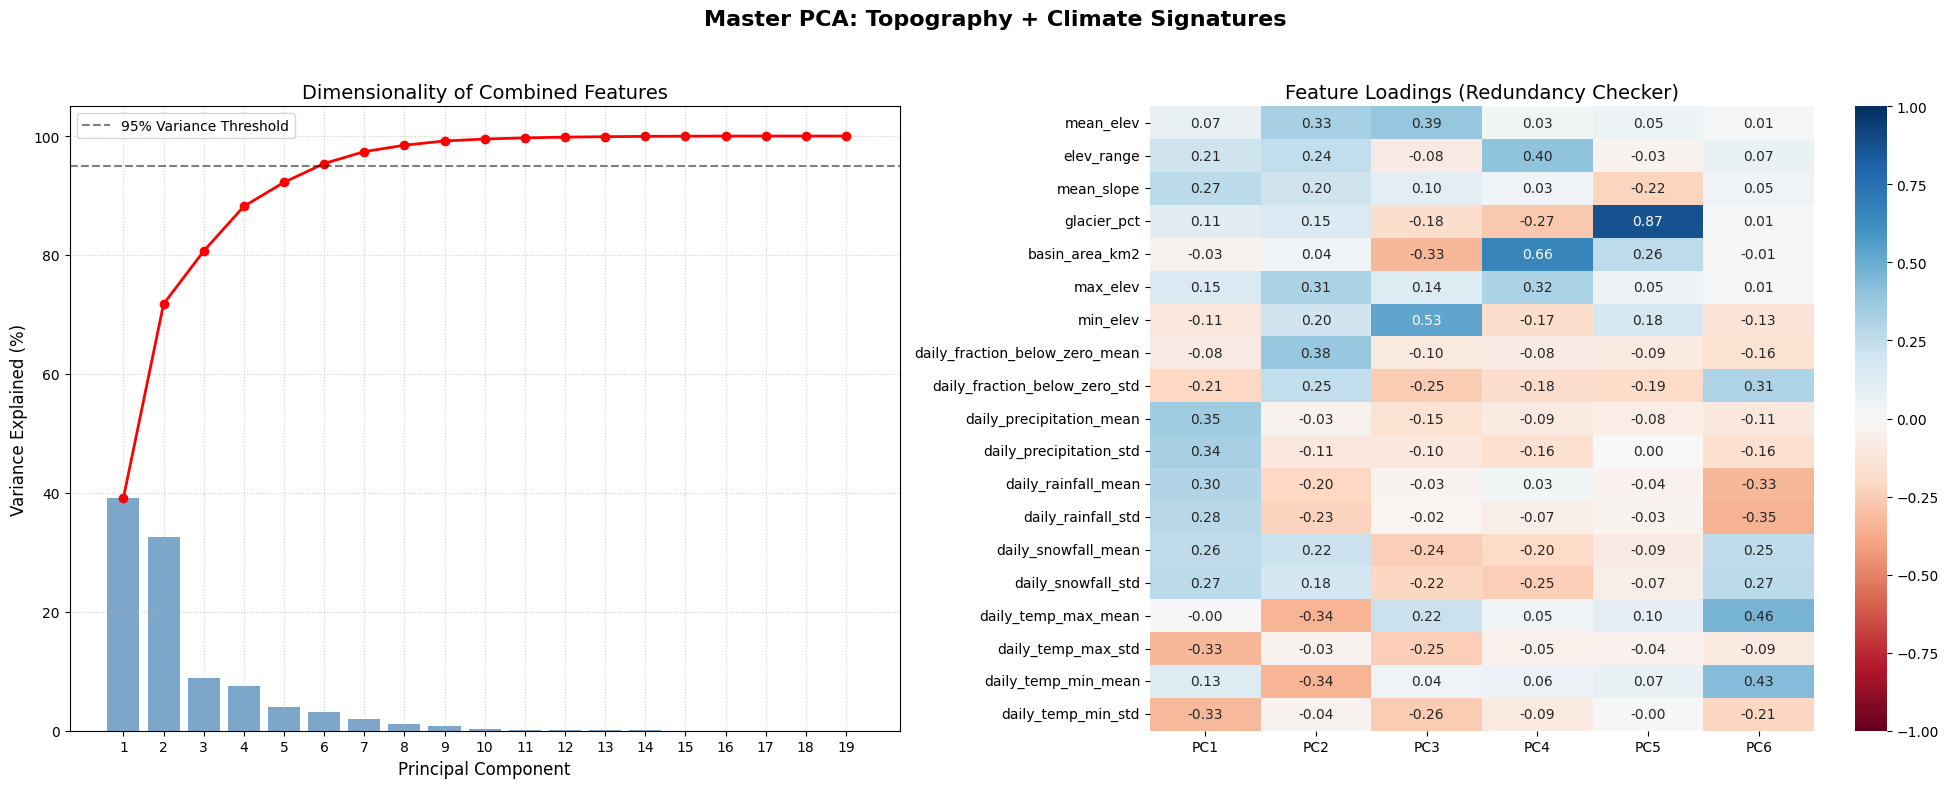

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

from src.config import PROCESSED_DATA_DIR, CLIMATE_OUTPUT_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Aggregate Dynamic Climate Variables
# =========================================================
print("Aggregating dynamic climate files...")

climate_stats = []

# Iterate through all CSVs in the climate directory
for file in CLIMATE_OUTPUT_DIR.glob('*.csv'):
    var_name = file.stem  # e.g., 'prcp', 'tmax', etc.
    
    # Rows = Dates, Columns = Stations
    df_clim = pd.read_csv(file, index_col=0, parse_dates=True)
    
    # Calculate Mean and Std Dev for each station across the entire timeseries
    # This creates a spatial signature of the climate
    mean_series = df_clim.mean().rename(f'{var_name}_mean')
    std_series = df_clim.std().rename(f'{var_name}_std')
    
    climate_stats.extend([mean_series, std_series])

# Combine all climate stats into a single dataframe where Index = Station
df_climate = pd.concat(climate_stats, axis=1)
df_climate.index = df_climate.index.astype(str).str.strip().str.upper()

# =========================================================
# 2. Load Topography and Merge
# =========================================================
print("Loading static attributes and merging...")
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_attr.index = df_attr.index.astype(str).str.strip().str.upper()

# Merge climate and static features
df_combined = df_attr.merge(df_climate, left_index=True, right_index=True, how='inner')

# Define the features to test (Update topographic list as needed)
topo_features = ['mean_elev', 'elev_range', 'mean_slope', 'glacier_pct', 
                 'basin_area_km2', 'max_elev', 'min_elev']
climate_features = df_climate.columns.tolist()

features_to_test = topo_features + climate_features
available_features = [f for f in features_to_test if f in df_combined.columns]

# Drop NaNs and scale
df_pca = df_combined[available_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# =========================================================
# 3. Fit Master PCA & Plot
# =========================================================
print(f"Running PCA on {len(available_features)} total features...")
pca = PCA()
pca.fit(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Master PCA: Topography + Climate Signatures", fontsize=16, fontweight='bold')

# --- Scree Plot ---
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100
ax1.bar(range(1, len(available_features) + 1), pca.explained_variance_ratio_ * 100, alpha=0.7, color='steelblue')
ax1.plot(range(1, len(available_features) + 1), cumulative_variance, marker='o', color='red', linewidth=2)
ax1.set_title("Dimensionality of Combined Features", fontsize=14)
ax1.set_xlabel("Principal Component", fontsize=12)
ax1.set_ylabel("Variance Explained (%)", fontsize=12)
ax1.set_xticks(range(1, len(available_features) + 1))
ax1.axhline(y=95, color='k', linestyle='--', alpha=0.5, label='95% Variance Threshold')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Loadings Heatmap ---
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(available_features))], index=available_features)
num_pcs = min(6, len(available_features)) 
sns.heatmap(loadings.iloc[:, :num_pcs], annot=True, cmap='RdBu', center=0, vmax=1, vmin=-1, fmt='.2f', ax=ax2)
ax2.set_title("Feature Loadings (Redundancy Checker)", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Save this combined dataset so the next script can use it instantly
df_pca.to_csv(PROCESSED_DATA_DIR / "pca_master_features.csv")

Loading datasets...
Converting streamflow to mm/day...
Computing hydrological signatures based on Water Year (Starts Sept 1)...
Aggregating climate data and merging master dataset...

Evaluating chosen subset...
--------------------------------------------------
📊 FEATURE SUBSET EVALUATION
--------------------------------------------------
Features: glacier_pct, basin_area_km2, mean_slope, mean_elev, min_elev, max_elev, mean_cos_aspect, mean_sin_aspect, daily_temp_max_mean, daily_temp_max_std, daily_temp_min_mean, daily_temp_min_std, daily_rainfall_mean, daily_rainfall_std, daily_snowfall_mean, daily_snowfall_std
Global Variance Explained:     93.7% (Inflated by inputs)
HYDROLOGIC VALIDATION SCORE:   78.4% (True Predictive Power)
--------------------------------------------------


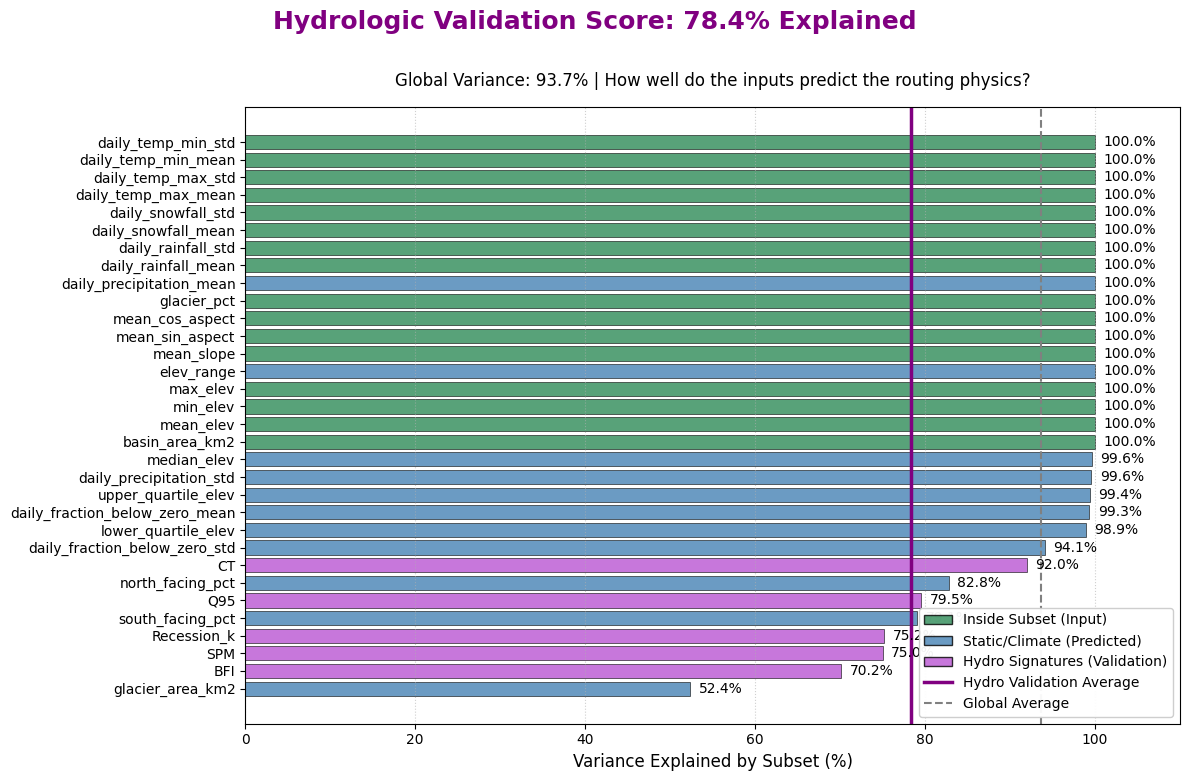


Calculating relative feature weights for hydrologic targets...


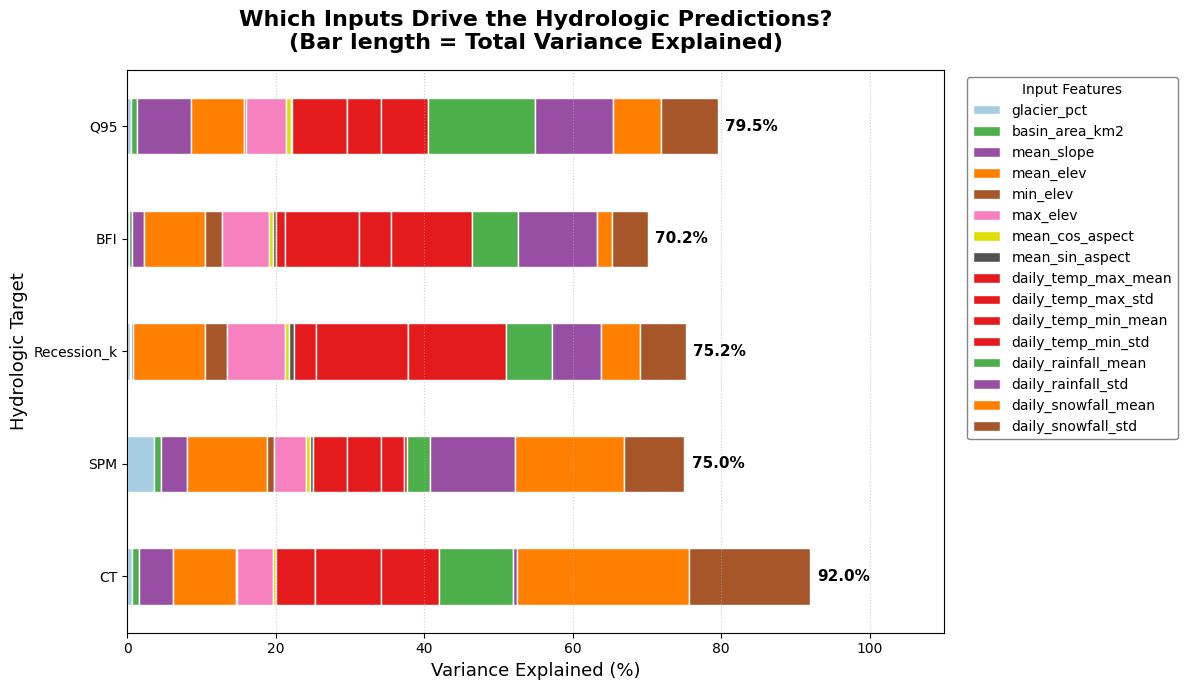

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
from pathlib import Path

# Adjust these imports to match your project structure
from src.config import PROCESSED_DATA_DIR, CLIMATE_OUTPUT_DIR

warnings.filterwarnings('ignore')

# 🎯 YOUR SELECTED FEATURES TO TEST 
# Edit this list to see how well it captures the whole system!
subset_to_test = [
    'glacier_pct', 
    # 'glacier_area_km2',
    'basin_area_km2',
    'mean_slope',
    'mean_elev',
    # 'elev_range',
    'min_elev',
    'max_elev',
    'mean_cos_aspect',
    'mean_sin_aspect',
    'daily_temp_max_mean',
    'daily_temp_max_std',
    'daily_temp_min_mean',
    'daily_temp_min_std',
    'daily_rainfall_mean',
    'daily_rainfall_std',
    'daily_snowfall_mean',
    'daily_snowfall_std'
]
# subset_to_test = [
#     'glacier_pct', 
#     # 'basin_area_km2',
#     # 'mean_slope',
#     # 'mean_elev',
#     # 'elev_range',
#     'daily_temp_max_mean',
#     'daily_temp_max_std',
#     'daily_temp_min_mean',
#     'daily_temp_min_std',
#     'daily_precipitation_mean',
#     'daily_precipitation_std'
# ]

# =========================================================
# HELPER FUNCTION: Lyne-Hollick Baseflow Filter
# =========================================================
def lyne_hollick_filter(q, alpha=0.925):
    """Calculates Baseflow using the Lyne-Hollick digital filter."""
    q_filled = q.interpolate(limit=5).fillna(0) # Interpolate short gaps
    q_vals = q_filled.values
    qf = np.zeros_like(q_vals)
    
    # Forward pass quickflow calculation
    qf[0] = q_vals[0]
    for t in range(1, len(q_vals)):
        qf[t] = alpha * qf[t-1] + ((1 + alpha) / 2) * (q_vals[t] - q_vals[t-1])
    
    qf = np.maximum(0, qf) # Quickflow cannot be negative
    baseflow = q_vals - qf
    baseflow = np.clip(baseflow, 0, q_vals) # Baseflow cannot be negative or exceed total flow
    return baseflow

# =========================================================
# 1. Load Data
# =========================================================
print("Loading datasets...")
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_attr.index = df_attr.index.astype(str).str.strip().str.upper()

# Load streamflow
df_stream = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col=0, parse_dates=True)
df_stream.columns = df_stream.columns.astype(str).str.strip().str.upper()

# =========================================================
# 2. Convert Streamflow (m^3/s to mm/day)
# =========================================================
print("Converting streamflow to mm/day...")
# Formula: Depth (mm/day) = (Q (m^3/s) * 86400 s/day) / (Area (km^2) * 1,000,000 m^2/km^2) * 1000 mm/m
# Simplified: Q_mm = Q_m3s * 86.4 / Area_km2
for col in df_stream.columns:
    if col in df_attr.index and 'basin_area_km2' in df_attr.columns:
        area = df_attr.loc[col, 'basin_area_km2']
        if pd.notna(area) and area > 0:
            df_stream[col] = (df_stream[col] * 86.4) / area
        else:
            df_stream[col] = np.nan
    else:
        df_stream[col] = np.nan

# =========================================================
# 3. Compute Hydrograph Signatures (Water Year Adjusted)
# =========================================================
print("Computing hydrological signatures based on Water Year (Starts Sept 1)...")
hydro_metrics = []

for station in df_stream.columns:
    series = df_stream[station].dropna()
    if series.empty:
        continue
        
    # --- NEW: Compute Water Year & Day of Water Year (DOWY) ---
    # If the month is Sept (9) or later, it belongs to the *next* calendar's Water Year
    wy = np.where(series.index.month >= 9, series.index.year + 1, series.index.year)
    
    # Calculate the start date of the Water Year for every single row (Sept 1 of the previous year)
    wy_starts = pd.to_datetime((wy - 1).astype(str) + '-09-01')
    
    # DOWY: Sept 1 = Day 1, Sept 2 = Day 2... Aug 31 = Day 365/366
    dowy = (series.index - wy_starts).days + 1
    
    # Create a temporary dataframe with our new time trackers
    df_temp = pd.DataFrame({
        'flow': series.values, 
        'WY': wy, 
        'DOWY': dowy, 
        'month': series.index.month
    }, index=series.index)
    
    station_metrics = {'Station': station}
    ct_list, spm_list, k_list, bfi_list, q95_list = [], [], [], [], []
    
    # Iterate through each Water Year instead of Calendar Year
    for current_wy in df_temp['WY'].unique():
        df_y = df_temp[df_temp['WY'] == current_wy]
        
        # Enforce 80% coverage rule (approx 292 days of the WATER YEAR)
        if len(df_y) < 292:
            continue
            
        # 1. Center of Timing (CT) - Now uses Days Since Sept 1 (DOWY)
        annual_total = df_y['flow'].sum()
        if annual_total > 0:
            cumsum = df_y['flow'].cumsum()
            # Find the Day of Water Year where 50% of flow has passed
            dowy_50 = df_y[cumsum >= 0.5 * annual_total]['DOWY'].values
            if len(dowy_50) > 0:
                ct_list.append(dowy_50[0])
                
        # 2. Spring Pulse Magnitude (SPM) (April 1 to July 31)
        melt_season = df_y[df_y['month'].isin([4, 5, 6, 7])]
        if not melt_season.empty and df_y['flow'].mean() > 0:
            spm_list.append(melt_season['flow'].mean() / df_y['flow'].mean())
            
        # 3. Recession Constant (k)
        q_t = df_y['flow'].values[1:]
        q_t1 = df_y['flow'].values[:-1]
        recession_mask = (q_t < q_t1) & (q_t > 0)
        if np.any(recession_mask):
            k_vals = np.log(q_t1[recession_mask] / q_t[recession_mask])
            k_list.append(np.median(k_vals))
            
        # 4. Baseflow Index (BFI)
        baseflow = lyne_hollick_filter(df_y['flow'])
        if np.sum(df_y['flow'].values) > 0:
            bfi_list.append(np.sum(baseflow) / np.sum(df_y['flow'].values))
            
        # 5. Low-Flow Quantile (Q95)
        q95_list.append(np.percentile(df_y['flow'].values, 5))

    # Average metrics across all valid Water Years for the station
    if ct_list: station_metrics['CT'] = np.mean(ct_list)
    if spm_list: station_metrics['SPM'] = np.mean(spm_list)
    if k_list: station_metrics['Recession_k'] = np.mean(k_list)
    if bfi_list: station_metrics['BFI'] = np.mean(bfi_list)
    if q95_list: station_metrics['Q95'] = np.mean(q95_list)
        
    hydro_metrics.append(station_metrics)

df_hydro = pd.DataFrame(hydro_metrics).set_index('Station')

# =========================================================
# 4. Aggregate Climate & Merge Everything
# =========================================================
print("Aggregating climate data and merging master dataset...")
climate_stats = []
for file in CLIMATE_OUTPUT_DIR.glob('*.csv'):
    var_name = file.stem
    df_clim = pd.read_csv(file, index_col=0, parse_dates=True)
    climate_stats.append(df_clim.mean().rename(f'{var_name}_mean'))
    climate_stats.append(df_clim.std().rename(f'{var_name}_std'))

df_climate = pd.concat(climate_stats, axis=1)
df_climate.index = df_climate.index.astype(str).str.strip().str.upper()

# MASTER MERGE
df_master = df_attr.merge(df_climate, left_index=True, right_index=True, how='inner')
df_master = df_master.merge(df_hydro, left_index=True, right_index=True, how='inner')

# Drop NaNs to ensure clean PCA
df_master = df_master.select_dtypes(include=[np.number]).dropna()

# =========================================================
# 5. Total Variance Explained (Linear Reconstruction)
# =========================================================
print("\nEvaluating chosen subset...")

missing = [f for f in subset_to_test if f not in df_master.columns]
if missing: raise ValueError(f"Missing features: {missing}")

# Define the Holdout Validation Target (Hydrology)
hydro_signatures = ['CT', 'SPM', 'Recession_k', 'BFI', 'Q95']

# Standardize
scaler = StandardScaler()
X_full = pd.DataFrame(scaler.fit_transform(df_master), columns=df_master.columns, index=df_master.index)
X_sub = X_full[subset_to_test]

# Reconstruct
explained_variances = {}
model = LinearRegression()

for target_feat in X_full.columns:
    if target_feat in subset_to_test:
        explained_variances[target_feat] = 1.0 
    else:
        model.fit(X_sub, X_full[target_feat])
        r2 = model.score(X_sub, X_full[target_feat])
        explained_variances[target_feat] = max(0, r2)

# Calculate Global Average
total_var = np.mean(list(explained_variances.values())) * 100

# Calculate Hydrologic Holdout Validation Average
hydro_r2_scores = [explained_variances[f] for f in hydro_signatures if f in explained_variances]
hydro_var = np.mean(hydro_r2_scores) * 100 if hydro_r2_scores else 0

print("-" * 50)
print(f"📊 FEATURE SUBSET EVALUATION")
print("-" * 50)
print(f"Features: {', '.join(subset_to_test)}")
print(f"Global Variance Explained:     {total_var:.1f}% (Inflated by inputs)")
print(f"HYDROLOGIC VALIDATION SCORE:   {hydro_var:.1f}% (True Predictive Power)")
print("-" * 50)

# =========================================================
# 6. Plotting 
# =========================================================
sorted_vars = dict(sorted(explained_variances.items(), key=lambda item: item[1]))
features = list(sorted_vars.keys())
variances = [v * 100 for v in sorted_vars.values()]

# Color Logic
colors = []
for f in features:
    if f in subset_to_test:
        colors.append('seagreen')
    elif f in hydro_signatures:
        colors.append('mediumorchid')
    else:
        colors.append('steelblue')

fig, ax = plt.subplots(figsize=(12, max(8, len(features) * 0.25)))
fig.suptitle(f"Hydrologic Validation Score: {hydro_var:.1f}% Explained", fontsize=18, fontweight='bold', color='purple', y=0.97)

bars = ax.barh(features, variances, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', ha='left', fontsize=10)

ax.set_xlabel("Variance Explained by Subset (%)", fontsize=12)
ax.set_title(f"Global Variance: {total_var:.1f}% | How well do the inputs predict the routing physics?", fontsize=12, pad=15)
ax.set_xlim(0, 110)

# Add Vertical Lines for both averages
ax.axvline(x=total_var, color='gray', linestyle='--', linewidth=1.5, label=f'Global Avg ({total_var:.1f}%)')
ax.axvline(x=hydro_var, color='purple', linestyle='-', linewidth=2.5, label=f'Hydro Validation Avg ({hydro_var:.1f}%)')

ax.grid(True, axis='x', linestyle=':', alpha=0.6)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Legend
legend_elements = [
    Patch(facecolor='seagreen', edgecolor='black', alpha=0.8, label='Inside Subset (Input)'),
    Patch(facecolor='steelblue', edgecolor='black', alpha=0.8, label='Static/Climate (Predicted)'),
    Patch(facecolor='mediumorchid', edgecolor='black', alpha=0.8, label='Hydro Signatures (Validation)'),
    Line2D([0], [0], color='purple', lw=2.5, label='Hydro Validation Average'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label='Global Average')
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.95)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# =========================================================
# 7. Feature Importance Breakdown (Stacked Contributions)
# =========================================================
print("\nCalculating relative feature weights for hydrologic targets...")

# We only want to plot how the inputs predict the HYDROLOGIC signatures
hydro_targets = ['CT', 'SPM', 'Recession_k', 'BFI', 'Q95']
available_hydro = [f for f in hydro_targets if f in X_full.columns]

importance_records = []

for target in available_hydro:
    # Fit the model
    model.fit(X_sub, X_full[target])
    r2 = max(0, model.score(X_sub, X_full[target]))
    
    # Extract coefficients (absolute values because negative correlation is still high importance)
    abs_coefs = np.abs(model.coef_)
    
    if np.sum(abs_coefs) == 0 or r2 == 0:
        # If the model completely fails, everything is 0
        contributions = np.zeros(len(subset_to_test))
    else:
        # Normalize coefficients so they sum to 1, then multiply by the total R2
        normalized_weights = abs_coefs / np.sum(abs_coefs)
        contributions = normalized_weights * (r2 * 100) # Convert to percentage
        
    # Store results
    record = {input_feat: weight for input_feat, weight in zip(subset_to_test, contributions)}
    record['Target'] = target
    importance_records.append(record)

df_importance = pd.DataFrame(importance_records).set_index('Target')

# =========================================================
# 8. Plotting the Stacked Weights (Semantic Coloring)
# =========================================================

# 1. Define a highly distinct palette for Static Features
# (Green, Purple, Orange, Brown, Pink, Yellow, Dark Gray)
static_palette = ['#4daf4a', '#984ea3', '#ff7f00', '#a65628', '#f781bf', '#dede00', '#525252']
static_idx = 0

color_map = {}

# 2. Assign colors semantically
for feat in df_importance.columns:
    feat_lower = feat.lower()
    
    # Dynamic Variables (Grouped by Color Family)
    if 'prcp' in feat_lower or 'precip' in feat_lower:
        color_map[feat] = '#377eb8'  # Deep Blue for all Precipitation
    elif 'tmax' in feat_lower or 'temp' in feat_lower:
        color_map[feat] = '#e41a1c'  # Vibrant Red for all Temperature
        
    # Specific Topo/Landcover Overrides
    elif 'glacier' in feat_lower:
        color_map[feat] = '#a6cee3'  # Icy Cyan/Light Blue for Glaciers
        
    # All other Static Attributes get forced into distinct, contrasting colors
    else:
        color_map[feat] = static_palette[static_idx % len(static_palette)]
        static_idx += 1

# Extract the colors in the exact order of the dataframe columns
ordered_colors = [color_map[col] for col in df_importance.columns]

fig, ax = plt.subplots(figsize=(12, 7))

# Create the stacked bar chart using our semantic colors
df_importance.plot(kind='barh', stacked=True, color=ordered_colors, ax=ax, edgecolor='white', linewidth=1.0)

# Add text labels showing the total variance explained at the end of each bar
for i, total_val in enumerate(df_importance.sum(axis=1)):
    ax.text(total_val + 1, i, f"{total_val:.1f}%", va='center', fontweight='bold', fontsize=11, color='black')

ax.set_title("Which Inputs Drive the Hydrologic Predictions?\n(Bar length = Total Variance Explained)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Variance Explained (%)", fontsize=13)
ax.set_ylabel("Hydrologic Target", fontsize=13)
ax.set_xlim(0, 110)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

# Format the legend to sit outside the plot area
ax.legend(title="Input Features", bbox_to_anchor=(1.02, 1), loc='upper left', framealpha=0.95, edgecolor='gray')

plt.tight_layout()
plt.show()

* CT: Center of mass timing of the flow.
* SPM: Spring pulse magnitude. How dominant is the melt pulse compared to the rest of the year.
* Recession_k: Recession constant in exponential decay. How quickly the flow declines after peak melt.
* BFI: Baseline flow index. The proportion of flow sustained by groundwater or glaciers.
* Q95: Low-flow quantile. Records the magnitude of low flows.